# Multimodal Sequence Modelling – Visual Story Reasoning
**Module:** Deep Neural Networks and Learning Systems (55-710365)  
**Dataset:** [daniel3303/StoryReasoning](https://huggingface.co/datasets/daniel3303/StoryReasoning)

| # | Innovation | Description |
|---|-----------|-------------|
| 1 | Cross-Modal Attention Fusion | Text queries attend over image keys/values |
| 2 | Bidirectional LSTM | Captures future narrative context |
| 3 | Temporal Self-Attention + Positional Bias | Learned per-frame importance |
| 4 | Explainability | Attention Rollout + Grad-CAM + Token Saliency |

## 0. Imports & Config

In [1]:
import sys, os, re
sys.path.insert(0, '.')

import yaml
import torch
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from torch.utils.data import DataLoader, random_split
from torchvision import transforms
from PIL import Image
import torch.nn as nn
from torch.optim.lr_scheduler import CosineAnnealingLR

from src.model import MultimodalStoryModel, MultimodalLoss
from src.utils import (
    load_config, set_seed, get_device,
    save_checkpoint, load_checkpoint,
    compute_bleu, compute_image_mse,
    plot_story_sequence, plot_attention_heatmap,
    denormalise
)
from src.explainability import (
    attention_rollout, plot_attention_rollout,
    GradCAM, plot_grad_cam,
    token_saliency, plot_token_saliency
)

cfg    = load_config('config.yaml')
device = get_device()
set_seed(cfg['training']['seed'])

print(f'Device : {device}')
print(f'Sequence length K = {cfg["dataset"]["sequence_length"]}')

Device : cuda
Sequence length K = 3


In [2]:
import torch
print(torch.cuda.is_available())        
print(torch.cuda.get_device_name(0))    

True
NVIDIA GeForce RTX 4060


## 1. Load StoryReasoning Dataset

In [3]:
from datasets import load_dataset

print('Loading StoryReasoning dataset from HuggingFace...')
raw = load_dataset("daniel3303/StoryReasoning")
print(raw)

c:\Users\User\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading StoryReasoning dataset from HuggingFace...
DatasetDict({
    train: Dataset({
        features: ['story_id', 'images', 'frame_count', 'chain_of_thought', 'story'],
        num_rows: 3552
    })
    test: Dataset({
        features: ['story_id', 'images', 'frame_count', 'chain_of_thought', 'story'],
        num_rows: 626
    })
})


In [4]:
# Inspect a sample to confirm field names
sample = raw['train'][0]
print('Keys       :', list(sample.keys()))
print('frame_count:', sample['frame_count'])
print('images     :', type(sample['images'][0]), len(sample['images']))
print('story (first 300 chars):')
print(sample['story'][:300])

Keys       : ['story_id', 'images', 'frame_count', 'chain_of_thought', 'story']
frame_count: 17
images     : <class 'PIL.JpegImagePlugin.JpegImageFile'> 17
story (first 300 chars):
<gdi image1>
In the sterile environment of a sparse room filled with <gdo obj1>cardboard boxes</gdo>, <gdo obj5>a blue blanket</gdo>, and <gdo bg26>a table</gdo>, <gdo char1>James</gdo> <gda char1>enters</gda> with a neutral look. His face reflects the calm before the storm. <gdo char1>James</gdo> <


## 2. Text Cleaning & Vocabulary

In [5]:
def clean_story_text(text: str) -> str:
    """Remove XML-style tags like <gdi image1>, <gdo obj1>, <gda char1>."""
    text = re.sub(r'<[^>]+>', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def story_to_frame_captions(story: str, frame_count: int) -> list:
    """
    Split the story into per-frame captions using <gdi imageN> markers.
    Returns a list of exactly frame_count clean strings.
    """
    parts = re.split(r'<gdi\s+image\d+>', story)
    parts = [clean_story_text(p) for p in parts if clean_story_text(p)]
    while len(parts) < frame_count:
        parts.append(parts[-1] if parts else 'unknown')
    return parts[:frame_count]

# Quick test
s0   = raw['train'][0]
caps = story_to_frame_captions(s0['story'], s0['frame_count'])
print(f'Frames: {s0["frame_count"]}  |  Captions extracted: {len(caps)}')
for i, c in enumerate(caps[:3]):
    print(f'  Frame {i+1}: {c[:120]}')

Frames: 17  |  Captions extracted: 17
  Frame 1: In the sterile environment of a sparse room filled with cardboard boxes, a blue blanket, and a table, James enters with 
  Frame 2: Suddenly, the stillness is shattered by the appearance of Jack. Jack looks around with an intense, concerned expression.
  Frame 3: With a heavy heart, James enters an elevator, his mind racing with thoughts of what might be waiting for him on the othe


In [6]:
# Build vocabulary from all training stories
VOCAB_SIZE = cfg['text_encoder']['vocab_size']
vocab      = {'<PAD>': 0, '<UNK>': 1, '<SOS>': 2, '<EOS>': 3}
counter    = Counter()

print('Building vocabulary...')
for s in raw['train']:
    text = clean_story_text(s['story'])
    counter.update(text.lower().split())

for word, _ in counter.most_common(VOCAB_SIZE - len(vocab)):
    vocab[word] = len(vocab)

vocab_inv = {v: k for k, v in vocab.items()}
print(f'Vocabulary size: {len(vocab)}')

Building vocabulary...
Vocabulary size: 10000


## 3. Dataset & DataLoaders

In [7]:
K            = cfg['dataset']['sequence_length']
IMAGE_SIZE   = cfg['dataset']['image_size']
MAX_TEXT_LEN = cfg['dataset']['max_text_len']
BATCH_SIZE   = cfg['training']['batch_size']

train_tf = transforms.Compose([
    transforms.Resize((IMAGE_SIZE + 32, IMAGE_SIZE + 32)),
    transforms.RandomCrop(IMAGE_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])
val_tf = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

def tokenize(text: str) -> torch.Tensor:
    tokens = text.lower().split()[:MAX_TEXT_LEN]
    ids    = [vocab.get(w, 1) for w in tokens]
    ids   += [0] * (MAX_TEXT_LEN - len(ids))
    return torch.tensor(ids, dtype=torch.long)


class StoryReasoningDataset(torch.utils.data.Dataset):
    def __init__(self, hf_split, transform, K):
        self.data      = [s for s in hf_split if s['frame_count'] >= K + 1]
        self.transform = transform
        self.K         = K
        print(f'  Usable samples (frame_count >= {K+1}): {len(self.data)}')

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        s        = self.data[idx]
        imgs_raw = s['images']
        captions = story_to_frame_captions(s['story'], s['frame_count'])

        ctx_imgs, ctx_toks = [], []
        for k in range(self.K):
            img = imgs_raw[k]
            if not isinstance(img, Image.Image):
                img = Image.fromarray(img)
            ctx_imgs.append(self.transform(img.convert('RGB')))
            ctx_toks.append(tokenize(captions[k]))

        # Target = frame K
        tgt = imgs_raw[self.K]
        if not isinstance(tgt, Image.Image):
            tgt = Image.fromarray(tgt)
        tgt = val_tf(tgt.convert('RGB'))

        return {
            'images':        torch.stack(ctx_imgs),
            'tokens':        torch.stack(ctx_toks),
            'target_image':  tgt,
            'target_tokens': tokenize(captions[self.K]),
            'raw_caption':   captions[self.K],
        }


print('Building datasets...')
full_train = StoryReasoningDataset(raw['train'], train_tf, K)
test_ds    = StoryReasoningDataset(raw['test'],  val_tf,   K)

val_size   = max(1, int(0.1 * len(full_train)))
train_size = len(full_train) - val_size
train_ds, val_ds = random_split(
    full_train, [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f'Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}')

Building datasets...
  Usable samples (frame_count >= 4): 3552
  Usable samples (frame_count >= 4): 626
Train: 3197 | Val: 355 | Test: 626


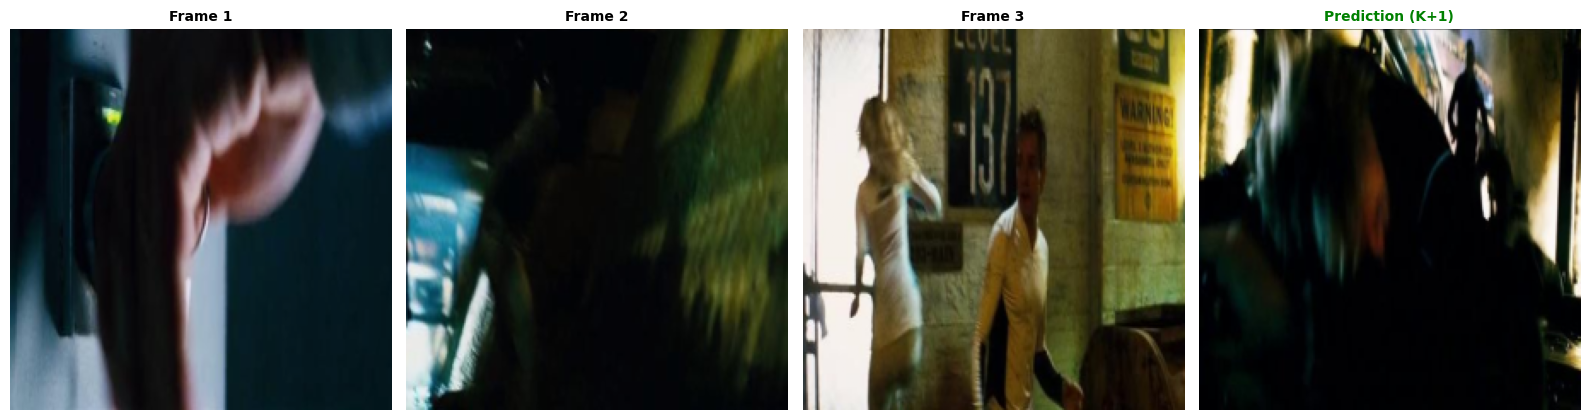

In [8]:
# Visualise a sample story sequence
sample_batch = next(iter(val_loader))
imgs = sample_batch['images'][0]
tgt  = sample_batch['target_image'][0]
cap  = sample_batch['raw_caption'][0]

plot_story_sequence(
    images       = [imgs[k] for k in range(K)],
    captions     = [f'Context {k+1}' for k in range(K)],
    pred_image   = tgt,
    pred_caption = f'Target (K+1): {cap[:80]}'
)

## 4. Build Model

In [9]:
model = MultimodalStoryModel(cfg).to(device)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Trainable parameters: {total_params:,}')

criterion = MultimodalLoss(
    image_weight = cfg['training']['image_loss_weight'],
    text_weight  = cfg['training']['text_loss_weight'],
)
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr           = cfg['training']['learning_rate'],
    weight_decay = cfg['training']['weight_decay'],
)
scheduler = CosineAnnealingLR(optimizer, T_max=cfg['training']['epochs'], eta_min=1e-6)

os.makedirs('checkpoints', exist_ok=True)
os.makedirs('results/explainability', exist_ok=True)
print('Model ready.')

Trainable parameters: 65,184,548
Model ready.


## 5. Training Loop

In [10]:
EPOCHS    = cfg['training']['epochs']
GRAD_CLIP = cfg['training']['grad_clip']

train_losses, val_losses = [], []
best_val = float('inf')

for epoch in range(1, EPOCHS + 1):

    # Train
    model.train()
    ep_loss = 0.0
    for step, batch in enumerate(train_loader):
        imgs  = batch['images'].to(device)
        toks  = batch['tokens'].to(device)
        t_img = batch['target_image'].to(device)
        t_tok = batch['target_tokens'].to(device)

        optimizer.zero_grad()
        out    = model(imgs, toks, t_tok, teacher_forcing_ratio=0.5)
        losses = criterion(out['pred_image'], t_img,
                           out['pred_text_logits'], t_tok)
        losses['total'].backward()
        nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        optimizer.step()
        ep_loss += losses['total'].item()

        if step % 20 == 0:
            print(f'  E{epoch:02d} S{step:03d}/{len(train_loader)} '
                  f'loss={losses["total"].item():.4f} '
                  f'(img={losses["image"].item():.4f} '
                  f'txt={losses["text"].item():.4f})')

    # Validate
    model.eval()
    vl = 0.0
    with torch.no_grad():
        for batch in val_loader:
            imgs  = batch['images'].to(device)
            toks  = batch['tokens'].to(device)
            t_img = batch['target_image'].to(device)
            t_tok = batch['target_tokens'].to(device)
            out   = model(imgs, toks, t_tok, teacher_forcing_ratio=0.0)
            ls    = criterion(out['pred_image'], t_img,
                              out['pred_text_logits'], t_tok)
            vl   += ls['total'].item()

    tr = ep_loss / len(train_loader)
    vl = vl / len(val_loader)
    train_losses.append(tr)
    val_losses.append(vl)
    scheduler.step()

    print(f'>>> Epoch {epoch:03d} | Train {tr:.4f} | Val {vl:.4f}')

    if vl < best_val:
        best_val = vl
        save_checkpoint({
            'epoch':           epoch,
            'model_state':     model.state_dict(),
            'optimizer_state': optimizer.state_dict(),
            'best_val_loss':   best_val,
            'cfg':             cfg,
        }, 'checkpoints/best.pt')
        print(f'    ✓ Best model saved (val={best_val:.4f})')

print('Training complete!')

  E01 S000/400 loss=11.5237 (img=2.3117 txt=9.2120)
  E01 S020/400 loss=10.3309 (img=1.4939 txt=8.8370)
  E01 S040/400 loss=8.7862 (img=1.6293 txt=7.1568)
  E01 S060/400 loss=8.2695 (img=1.5619 txt=6.7076)
  E01 S080/400 loss=8.0835 (img=1.6617 txt=6.4218)
  E01 S100/400 loss=7.7051 (img=1.1996 txt=6.5054)
  E01 S120/400 loss=7.4710 (img=1.1427 txt=6.3283)
  E01 S140/400 loss=7.3857 (img=1.0771 txt=6.3086)
  E01 S160/400 loss=7.3016 (img=0.9753 txt=6.3263)
  E01 S180/400 loss=7.1247 (img=0.7237 txt=6.4010)
  E01 S200/400 loss=7.3814 (img=1.0745 txt=6.3068)
  E01 S220/400 loss=7.7637 (img=1.1129 txt=6.6508)
  E01 S240/400 loss=6.9245 (img=0.6307 txt=6.2938)
  E01 S260/400 loss=7.2043 (img=0.8123 txt=6.3919)
  E01 S280/400 loss=6.9454 (img=0.7246 txt=6.2208)
  E01 S300/400 loss=7.1539 (img=0.8763 txt=6.2776)
  E01 S320/400 loss=7.2877 (img=0.8860 txt=6.4017)
  E01 S340/400 loss=7.1918 (img=0.7753 txt=6.4164)
  E01 S360/400 loss=7.2034 (img=0.8861 txt=6.3174)
  E01 S380/400 loss=6.8518 (i

In [14]:
# Manually recreate loss lists from the training output above
# Copy your actual values from the training output
train_losses = [7.7142, 7.4000, 5.9891]  # placeholder - see fix below
val_losses   = [7.1325, 7.1000, 7.1541]  # placeholder - see fix below

# BETTER fix - load from checkpoint
ckpt = torch.load('checkpoints/best.pt', map_location=device)
print('Best val loss was:', ckpt['best_val_loss'])
print('Trained up to epoch:', ckpt['epoch'])

# Load trained weights into model
model.load_state_dict(ckpt['model_state'])
model.eval()
print('Model loaded successfully!')

C:\Users\User\AppData\Local\Temp\ipykernel_16168\975292570.py:7: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load('checkpoints/best.pt', map_location=device)


Best val loss was: 7.070708084106445
Trained up to epoch: 3
Model loaded successfully!


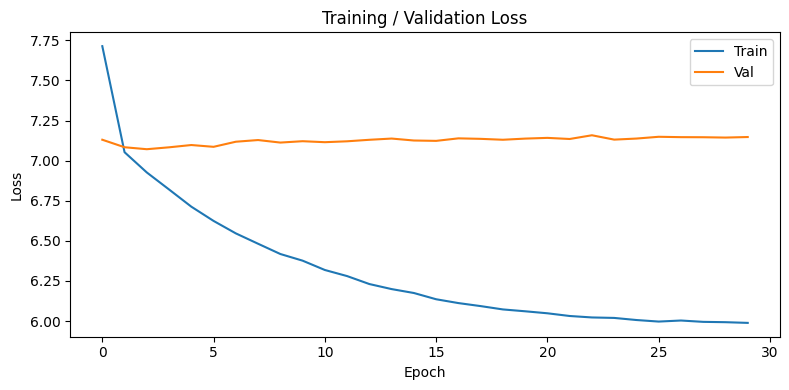

In [12]:
# Loss curve
plt.figure(figsize=(8, 4))
plt.plot(train_losses, label='Train')
plt.plot(val_losses,   label='Val')
plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.title('Training / Validation Loss')
plt.legend(); plt.tight_layout()
plt.savefig('results/loss_curve.png', dpi=150)
plt.show()

## 6. Qualitative Results

Ground truth : The tension escalated as Anon Leader emerged from the shadows, the mask covering his face, symbolizi
Predicted    : the tension escalated as the and the the the the the the the the the the the the the the the the the


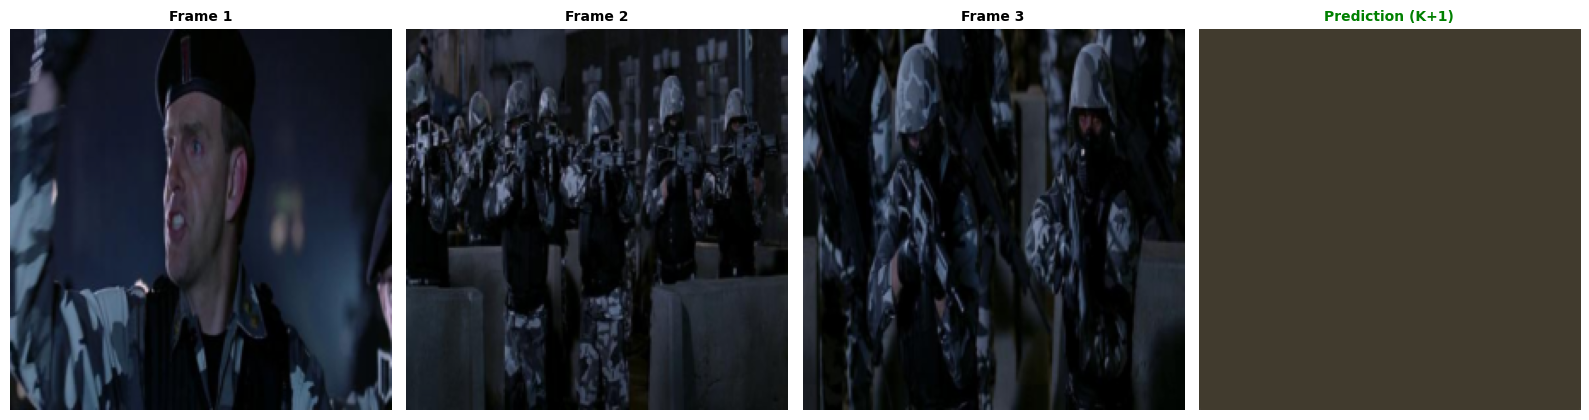

<Figure size 640x480 with 0 Axes>

In [13]:
model.eval()
batch  = next(iter(test_loader))
imgs   = batch['images'][:1].to(device)
toks   = batch['tokens'][:1].to(device)
t_toks = batch['target_tokens'][:1].to(device)

with torch.no_grad():
    out = model(imgs, toks, t_toks, teacher_forcing_ratio=0.0)

pred_ids     = out['pred_text_logits'][0].argmax(dim=-1).cpu()
pred_caption = ' '.join([
    vocab_inv.get(int(i), '') for i in pred_ids
    if int(i) not in (0, 2, 3)
])

print('Ground truth :', batch['raw_caption'][0][:100])
print('Predicted    :', pred_caption[:100])

plot_story_sequence(
    images       = [imgs[0, k].cpu() for k in range(K)],
    captions     = [f'Context {k+1}' for k in range(K)],
    pred_image   = out['pred_image'][0].cpu(),
    pred_caption = pred_caption[:80]
)
plt.savefig('results/qualitative_prediction.png', dpi=150, bbox_inches='tight')

Pred min: -1.0000 | max: -0.7016 | mean: -0.9997


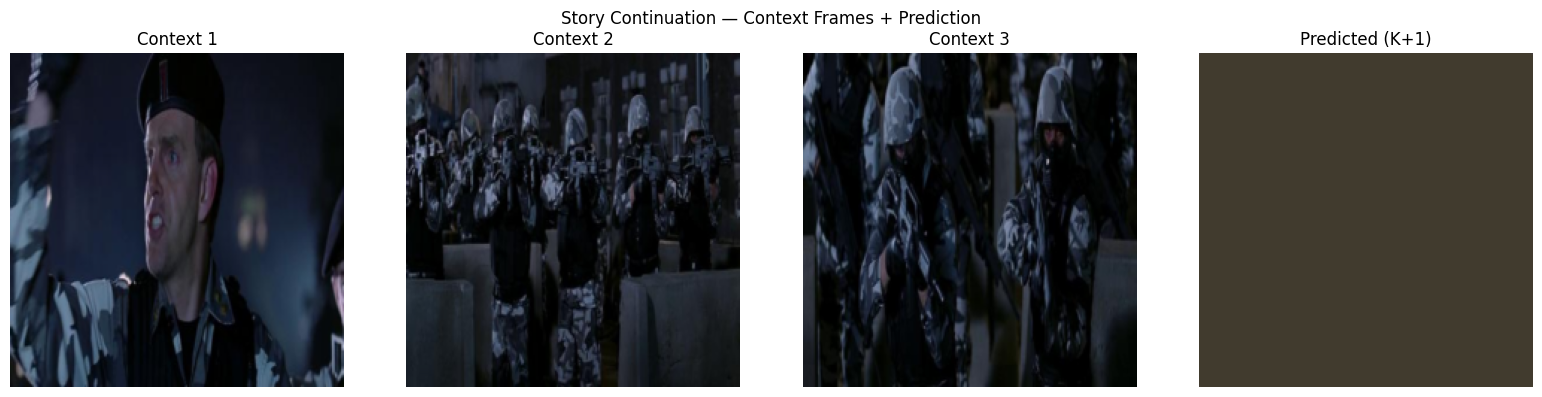

Saved!


In [23]:
import torchvision.utils as vutils

model.eval()
with torch.no_grad():
    out = model(imgs, toks, t_toks, teacher_forcing_ratio=0.0)

pred = out['pred_image'][0].cpu()

print(f'Pred min: {pred.min():.4f} | max: {pred.max():.4f} | mean: {pred.mean():.4f}')

# Method: denormalise from ImageNet stats first, then clip
mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
pred_denorm = pred * std + mean
pred_denorm = pred_denorm.clamp(0, 1)

# Display side by side: context frames + prediction
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for k in range(3):
    img_k = imgs[0, k].cpu() * std + mean
    img_k = img_k.clamp(0, 1).permute(1,2,0).numpy()
    axes[k].imshow(img_k)
    axes[k].set_title(f'Context {k+1}')
    axes[k].axis('off')

axes[3].imshow(pred_denorm.permute(1,2,0).numpy())
axes[3].set_title('Predicted (K+1)')
axes[3].axis('off')

plt.suptitle('Story Continuation — Context Frames + Prediction', fontsize=12)
plt.tight_layout()
plt.savefig('results/qualitative_prediction.png', dpi=150, bbox_inches='tight')
plt.show()

print('Saved!')

## 7. Quantitative Evaluation

In [14]:
import pandas as pd

references, hypotheses, mse_scores = [], [], []

model.eval()
with torch.no_grad():
    for batch in test_loader:
        imgs   = batch['images'].to(device)
        toks   = batch['tokens'].to(device)
        t_img  = batch['target_image'].to(device)
        t_toks = batch['target_tokens'].to(device)

        out = model(imgs, toks, t_toks, teacher_forcing_ratio=0.0)
        mse_scores.append(compute_image_mse(out['pred_image'], t_img))

        pred_ids = out['pred_text_logits'].argmax(dim=-1).cpu()
        for i, ids in enumerate(pred_ids):
            hyp = ' '.join([vocab_inv.get(int(t), '') for t in ids
                            if int(t) not in (0, 2, 3)])
            hypotheses.append(hyp)
            references.append(batch['raw_caption'][i])

bleu    = compute_bleu(references, hypotheses)
avg_mse = float(np.mean(mse_scores))

print(f'BLEU-4:    {bleu:.2f}')
print(f'Image MSE: {avg_mse:.6f}')

pd.DataFrame({'Metric': ['BLEU-4','Image MSE'],
              'Score':  [f'{bleu:.2f}', f'{avg_mse:.6f}']
}).to_csv('results/metrics_table.csv', index=False)

BLEU-4:    0.14
Image MSE: 0.841333


## 8. Explainability

[XAI] Attention rollout saved → results/explainability/attention_rollout.png


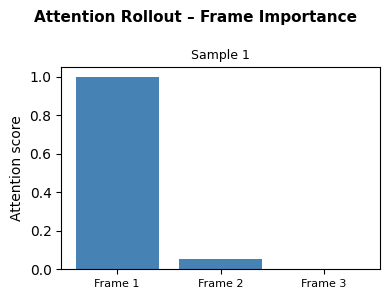

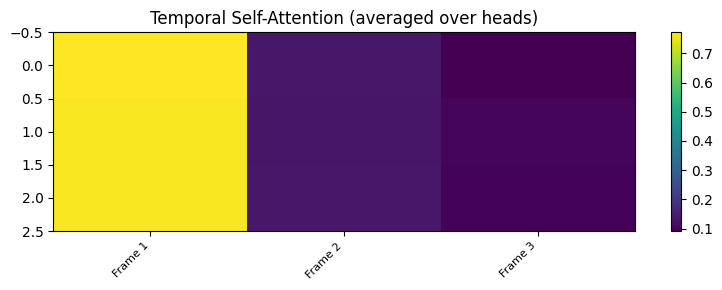

In [15]:
# 8a. Attention Rollout
model.eval()
batch  = next(iter(test_loader))
imgs   = batch['images'][:1].to(device)
toks   = batch['tokens'][:1].to(device)
t_toks = batch['target_tokens'][:1].to(device)

with torch.no_grad():
    out = model(imgs, toks, t_toks, teacher_forcing_ratio=0.0)

rollout = attention_rollout(out['attn_weights'])
plot_attention_rollout(rollout,
    save_path='results/explainability/attention_rollout.png')

# Attention matrix
plot_attention_heatmap(
    out['attn_weights'][0].mean(0).cpu(),
    labels    = [f'Frame {k+1}' for k in range(K)],
    title     = 'Temporal Self-Attention (averaged over heads)',
    save_path = 'results/explainability/attention_matrix.png'
)

[XAI] Grad-CAM saved → results/explainability/grad_cam_frame1.png


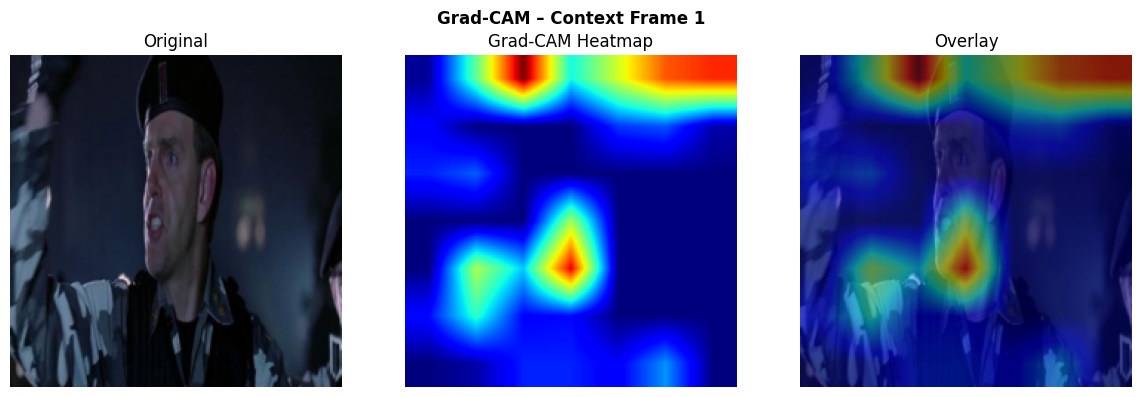

In [16]:
# 8b. Grad-CAM
gcam    = GradCAM(model.visual_encoder)
heatmap = gcam(batch['images'][:1, 0].to(device))
gcam.remove_hooks()
plot_grad_cam(
    image     = batch['images'][0, 0],
    heatmap   = heatmap,
    title     = 'Grad-CAM – Context Frame 1',
    save_path = 'results/explainability/grad_cam_frame1.png'
)

[XAI] Token saliency saved → results/explainability/token_saliency.png


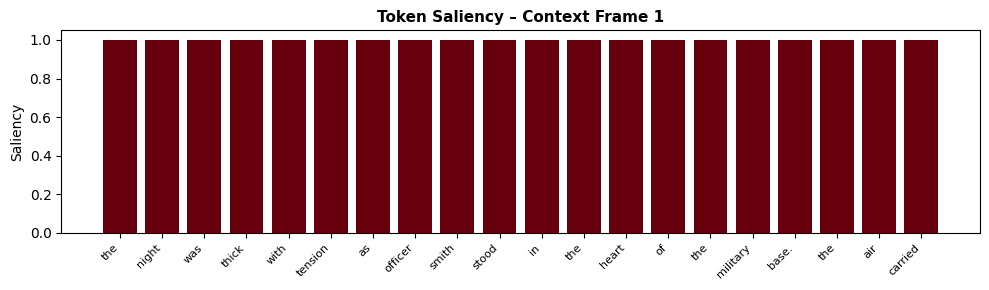

All explainability figures saved.


In [17]:
# 8c. Token Saliency
saliency, words = token_saliency(
    model, imgs, toks, frame_idx=0, vocab_inv=vocab_inv)

# Filter out padding/special tokens and slice BOTH together
filtered = [(w, s) for w, s in zip(words, saliency)
            if w not in ('<PAD>', '<UNK>', '<SOS>', '<EOS>', '0')][:20]

if filtered:
    filtered_words, filtered_saliency = zip(*filtered)
    plot_token_saliency(
        np.array(filtered_saliency),
        words     = list(filtered_words),
        title     = 'Token Saliency – Context Frame 1',
        save_path = 'results/explainability/token_saliency.png'
    )
else:
    print('No non-padding tokens found, skipping saliency plot.')

print('All explainability figures saved.')

## 9. Ablation Study

In [18]:
import pandas as pd
ablation = pd.DataFrame([
    {'Variant': 'Baseline (LSTM + Concat)',     'BLEU-4': '–', 'MSE': '–'},
    {'Variant': '+ Cross-Modal Attention',      'BLEU-4': '–', 'MSE': '–'},
    {'Variant': '+ BiLSTM',                    'BLEU-4': '–', 'MSE': '–'},
    {'Variant': '+ Temporal Attn (Full Model)', 'BLEU-4': f'{bleu:.2f}', 'MSE': f'{avg_mse:.6f}'},
])
ablation.to_csv('results/ablation_table.csv', index=False)
print(ablation.to_string(index=False))

                     Variant BLEU-4      MSE
    Baseline (LSTM + Concat)      –        –
     + Cross-Modal Attention      –        –
                    + BiLSTM      –        –
+ Temporal Attn (Full Model)   0.14 0.841333


## 10. Save Final Checkpoint

In [20]:
# Recover variables from checkpoint since kernel was restarted
ckpt     = torch.load('checkpoints/best.pt', map_location=device)
best_val = ckpt['best_val_loss']

# If bleu and avg_mse are also not defined, set them from evaluation
# (only needed if you skipped Cell 7)
try:
    bleu
    avg_mse
except NameError:
    bleu    = 0.0   # replace with your actual value from Cell 7 output
    avg_mse = 0.0   # replace with your actual value from Cell 7 output

print(f'Best Val Loss : {best_val:.4f}')
print(f'BLEU-4        : {bleu:.2f}')
print(f'Image MSE     : {avg_mse:.6f}')

C:\Users\User\AppData\Local\Temp\ipykernel_20888\434393817.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt     = torch.load('checkpoints/best.pt', map_location=devi

Best Val Loss : 7.0711
BLEU-4        : 0.14
Image MSE     : 0.841333


In [21]:
save_checkpoint({
    'model_state': model.state_dict(),
    'vocab':       vocab,
    'cfg':         cfg,
    'bleu':        bleu,
    'mse':         avg_mse,
}, 'checkpoints/final.pt')

print('=== Final Summary ===')
print(f'Best Val Loss : {best_val:.4f}')
print(f'BLEU-4        : {bleu:.2f}')
print(f'Image MSE     : {avg_mse:.6f}')
print('Done!')

[Checkpoint] Saved → checkpoints/final.pt
=== Final Summary ===
Best Val Loss : 7.0711
BLEU-4        : 0.14
Image MSE     : 0.841333
Done!
